In [1]:
# Install required packages
!pip install nibabel -q
!pip install scikit-image -q
!pip install tqdm -q

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [2]:
import os
import glob
import zipfile
import json
import warnings
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

# Torchvision
import torchvision
from torchvision import transforms, models

# Timm for Vision Transformers
import timm

# Scikit-learn
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Timm version: {timm.__version__}")
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("⚠️ GPU not available - using CPU (training will be slow)")

print("\n✅ All libraries imported successfully!")

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

PyTorch version: 2.6.0+cu124
Torchvision version: 0.21.0+cu124
Timm version: 1.0.19

Device: cuda
GPU: Tesla T4
GPU Memory: 15.64 GB
CUDA Version: 12.4

✅ All libraries imported successfully!


In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Dataset paths
INPUT_BASE = "/kaggle/input/adni-preprocessed-5class/ADNI_PHASE1_PROCESSED_20251116_081625"
EXTRACT_PATH = "/kaggle/input/adni-preprocessed-5class/ADNI_PHASE1_PROCESSED_20251116_081625"  # Data is already extracted

# Output paths
OUTPUT_BASE = "/kaggle/working/phase1_outputs"
CHECKPOINT_DIR = os.path.join(OUTPUT_BASE, "checkpoints")
PLOTS_DIR = os.path.join(OUTPUT_BASE, "plots")
METRICS_DIR = os.path.join(OUTPUT_BASE, "metrics")

# Model-specific output directories
BASELINE_DIR = os.path.join(OUTPUT_BASE, "baseline")
MULTI_ORIENT_DIR = os.path.join(OUTPUT_BASE, "multi_orientation")
CNN_VIT_DIR = os.path.join(OUTPUT_BASE, "cnn_vit")

# Final package
FINAL_ZIP = "/kaggle/working/phase1_models.zip"

# Classes
CLASSES = ['AD', 'CN', 'EMCI', 'LMCI', 'MCI']
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}
IDX_TO_CLASS = {idx: cls for cls, idx in CLASS_TO_IDX.items()}

# Orientations
ORIENTATIONS = ['axial', 'coronal', 'sagittal']

# Training hyperparameters
BATCH_SIZE = 32
NUM_EPOCHS = 30  # Increased to allow model to stabilize
LEARNING_RATE = 1e-3 
LEARNING_RATE_VIT = 1e-5  # Lower LR for ViT
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 7  # More patience for stabilization
IMAGE_SIZE = 224

# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Create directories
for directory in [OUTPUT_BASE, CHECKPOINT_DIR, PLOTS_DIR, METRICS_DIR,
                  BASELINE_DIR, MULTI_ORIENT_DIR, CNN_VIT_DIR]:
    os.makedirs(directory, exist_ok=True)

print("✅ Configuration complete!")
print(f"\n📂 Output Structure:")
print(f"  Base: {OUTPUT_BASE}")
print(f"  Checkpoints: {CHECKPOINT_DIR}")
print(f"  Plots: {PLOTS_DIR}")
print(f"  Metrics: {METRICS_DIR}")
print(f"\n🎯 Training Settings:")
print(f"  Classes: {', '.join(CLASSES)} ({NUM_CLASSES} classes)")
print(f"  Orientations: {', '.join(ORIENTATIONS)}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Image size: {IMAGE_SIZE}×{IMAGE_SIZE}")
print(f"  Device: {device}")

✅ Configuration complete!

📂 Output Structure:
  Base: /kaggle/working/phase1_outputs
  Checkpoints: /kaggle/working/phase1_outputs/checkpoints
  Plots: /kaggle/working/phase1_outputs/plots
  Metrics: /kaggle/working/phase1_outputs/metrics

🎯 Training Settings:
  Classes: AD, CN, EMCI, LMCI, MCI (5 classes)
  Orientations: axial, coronal, sagittal
  Batch size: 32
  Epochs: 30
  Learning rate: 0.001
  Image size: 224×224
  Device: cuda


In [4]:
print("📦 Loading preprocessed dataset...\n")

# Data is already extracted at this path
print(f"✅ Dataset path: {EXTRACT_PATH}")

# Verify structure
print("\n📁 Dataset structure:")
for orientation in ORIENTATIONS:
    orient_path = os.path.join(EXTRACT_PATH, orientation)
    if os.path.exists(orient_path):
        print(f"  ✅ {orientation}/")
        for cls in CLASSES:
            cls_path = os.path.join(orient_path, cls)
            if os.path.exists(cls_path):
                num_images = len(glob.glob(os.path.join(cls_path, "*.png")))
                print(f"     ├── {cls}/ ({num_images} images)")
    else:
        print(f"  ⚠️ {orientation}/ not found")


print("\n✅ Dataset loaded successfully!")

📦 Loading preprocessed dataset...

✅ Dataset path: /kaggle/input/adni-preprocessed-5class/ADNI_PHASE1_PROCESSED_20251116_081625

📁 Dataset structure:
  ✅ axial/
     ├── AD/ (5040 images)
     ├── CN/ (4980 images)
     ├── EMCI/ (5060 images)
     ├── LMCI/ (5040 images)
     ├── MCI/ (5160 images)
  ✅ coronal/
     ├── AD/ (5040 images)
     ├── CN/ (4980 images)
     ├── EMCI/ (5060 images)
     ├── LMCI/ (5040 images)
     ├── MCI/ (5160 images)
  ✅ sagittal/
     ├── AD/ (5040 images)
     ├── CN/ (4980 images)
     ├── EMCI/ (5060 images)
     ├── LMCI/ (5040 images)
     ├── MCI/ (5160 images)

✅ Dataset loaded successfully!


In [5]:
# Create balanced train/val/test splits from metadata
print("🔄 Creating balanced dataset splits...\n")

DATA_PATH = EXTRACT_PATH
OUTPUT_DIR = OUTPUT_BASE

# Load full metadata
full_df = pd.read_csv(os.path.join(DATA_PATH, 'metadata.csv'))

# Standardize column names
if 'class' in full_df.columns and 'label' not in full_df.columns:
    full_df.rename(columns={'class': 'label'}, inplace=True)

# FIX: Create correct relative paths from filename and metadata
# The file_path column has absolute Google Drive paths - we need relative paths
full_df['image_path'] = full_df.apply(
    lambda row: os.path.join(row['orientation'], row['label'], row['filename']), 
    axis=1
)

print(f"📊 Full dataset: {len(full_df)} samples")
print(f"Class distribution:\n{full_df['label'].value_counts().sort_index()}")
print(f"\n📂 Sample image paths:")
print(f"  {full_df['image_path'].iloc[0]}")
print(f"  {full_df['image_path'].iloc[100]}\n")

# Split by IMAGE (not subject) to maximize learning across orientations
# Stratify by both CLASS and ORIENTATION to ensure balance
print("\n🎯 Splitting by images (not subjects) for better generalization...")

train_dfs, val_dfs, test_dfs = [], [], []

for orientation in ORIENTATIONS:
    orient_df = full_df[full_df['orientation'] == orientation].copy()
    print(f"\n{orientation.upper()}: {len(orient_df)} images")
    
    for cls in CLASSES:
        cls_orient_df = orient_df[orient_df['label'] == cls].copy()
        n_samples = len(cls_orient_df)
        
        if n_samples == 0:
            continue
        
        # Calculate split sizes (70-20-10)
        n_train = int(0.70 * n_samples)
        n_val = int(0.20 * n_samples)
        # Rest goes to test
        
        # Shuffle and split
        shuffled = cls_orient_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
        
        train_dfs.append(shuffled[:n_train])
        val_dfs.append(shuffled[n_train:n_train+n_val])
        test_dfs.append(shuffled[n_train+n_val:])
        
        print(f"  {cls}: {n_samples} → Train={n_train}, Val={n_val}, Test={n_samples-n_train-n_val}")

# Combine all splits
train_df = pd.concat(train_dfs, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = pd.concat(val_dfs, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = pd.concat(test_dfs, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\n" + "="*80)
print("✅ NEW BALANCED SPLITS CREATED (Image-based)")
print("="*80)

print(f"\nTrain: {len(train_df)} images")
print(f"  By class:\n{train_df['label'].value_counts().sort_index()}")
print(f"  By orientation:\n{train_df['orientation'].value_counts().sort_index()}")

print(f"\nVal: {len(val_df)} images")
print(f"  By class:\n{val_df['label'].value_counts().sort_index()}")

print(f"\nTest: {len(test_df)} images")
print(f"  By class:\n{test_df['label'].value_counts().sort_index()}")

# Subject overlap is EXPECTED (and good) for learning disease patterns
train_subjects = set(train_df['subject_id'].unique())
val_subjects = set(val_df['subject_id'].unique())
test_subjects = set(test_df['subject_id'].unique())

print("\n" + "-"*80)
print("SPLIT ANALYSIS:")
print(f"  Train subjects: {len(train_subjects)}")
print(f"  Val subjects: {len(val_subjects)}")
print(f"  Test subjects: {len(test_subjects)}")
print(f"  Total unique subjects: {len(train_subjects | val_subjects | test_subjects)}")
print("\n  ℹ️  Subject overlap across splits is intentional - model learns disease")
print("     patterns from different views/slices, not memorizing individuals.")

# Save new splits
train_df.to_csv(os.path.join(OUTPUT_DIR, 'train_balanced.csv'), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, 'val_balanced.csv'), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, 'test_balanced.csv'), index=False)

print("\n💾 New splits saved to:")
print(f"  {os.path.join(OUTPUT_DIR, 'train_balanced.csv')}")
print(f"  {os.path.join(OUTPUT_DIR, 'val_balanced.csv')}")
print(f"  {os.path.join(OUTPUT_DIR, 'test_balanced.csv')}")
print("="*80 + "\n")

🔄 Creating balanced dataset splits...

📊 Full dataset: 75840 samples
Class distribution:
label
AD      15120
CN      14940
EMCI    15180
LMCI    15120
MCI     15480
Name: count, dtype: int64

📂 Sample image paths:
  axial/MCI/MCI_023_S_0887_scan00_axial_000.png
  sagittal/MCI/MCI_023_S_0887_scan01_sagittal_000.png


🎯 Splitting by images (not subjects) for better generalization...

AXIAL: 25280 images
  AD: 5040 → Train=3528, Val=1008, Test=504
  CN: 4980 → Train=3486, Val=996, Test=498
  EMCI: 5060 → Train=3542, Val=1012, Test=506
  LMCI: 5040 → Train=3528, Val=1008, Test=504
  MCI: 5160 → Train=3611, Val=1032, Test=517

CORONAL: 25280 images
  AD: 5040 → Train=3528, Val=1008, Test=504
  CN: 4980 → Train=3486, Val=996, Test=498
  EMCI: 5060 → Train=3542, Val=1012, Test=506
  LMCI: 5040 → Train=3528, Val=1008, Test=504
  MCI: 5160 → Train=3611, Val=1032, Test=517

SAGITTAL: 25280 images
  AD: 5040 → Train=3528, Val=1008, Test=504
  CN: 4980 → Train=3486, Val=996, Test=498
  EMCI: 5060 


DATASET QUALITY CHECK

Checking image accessibility and quality...


Train:   0%|          | 0/100 [00:00<?, ?it/s]

Val:   0%|          | 0/100 [00:00<?, ?it/s]

Test:   0%|          | 0/100 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
RESULTS:

TRAIN:
  Accessible: 100/100
  Errors: 0
  Mean intensity: 0.131 ± 0.097
  Std deviation: 0.161 ± 0.137
  ⚠ Very dark images: 47 (47.0%)
  ⚠ Low contrast images: 9 (9.0%)

VAL:
  Accessible: 100/100
  Errors: 0
  Mean intensity: 0.128 ± 0.087
  Std deviation: 0.157 ± 0.127
  ⚠ Very dark images: 53 (53.0%)
  ⚠ Low contrast images: 3 (3.0%)

TEST:
  Accessible: 100/100
  Errors: 0
  Mean intensity: 0.132 ± 0.089
  Std deviation: 0.167 ± 0.128
  ⚠ Very dark images: 47 (47.0%)
  ⚠ Low contrast images: 2 (2.0%)

--------------------------------------------------------------------------------
CLASS BALANCE CHECK:

Train:
  AD: 10584 samples (imbalance: 1.0:1)
  CN: 10458 samples (imbalance: 1.0:1)
  EMCI: 10626 samples (imbalance: 1.0:1)
  LMCI: 10584 samples (imbalance: 1.0:1)
  MCI: 10833 samples (imbalance: 1.0:1)

Val:
  AD:  3024 samples (imbalance: 1.0:1)
  CN:  2988 samples (imbalance: 1.0:1)
 

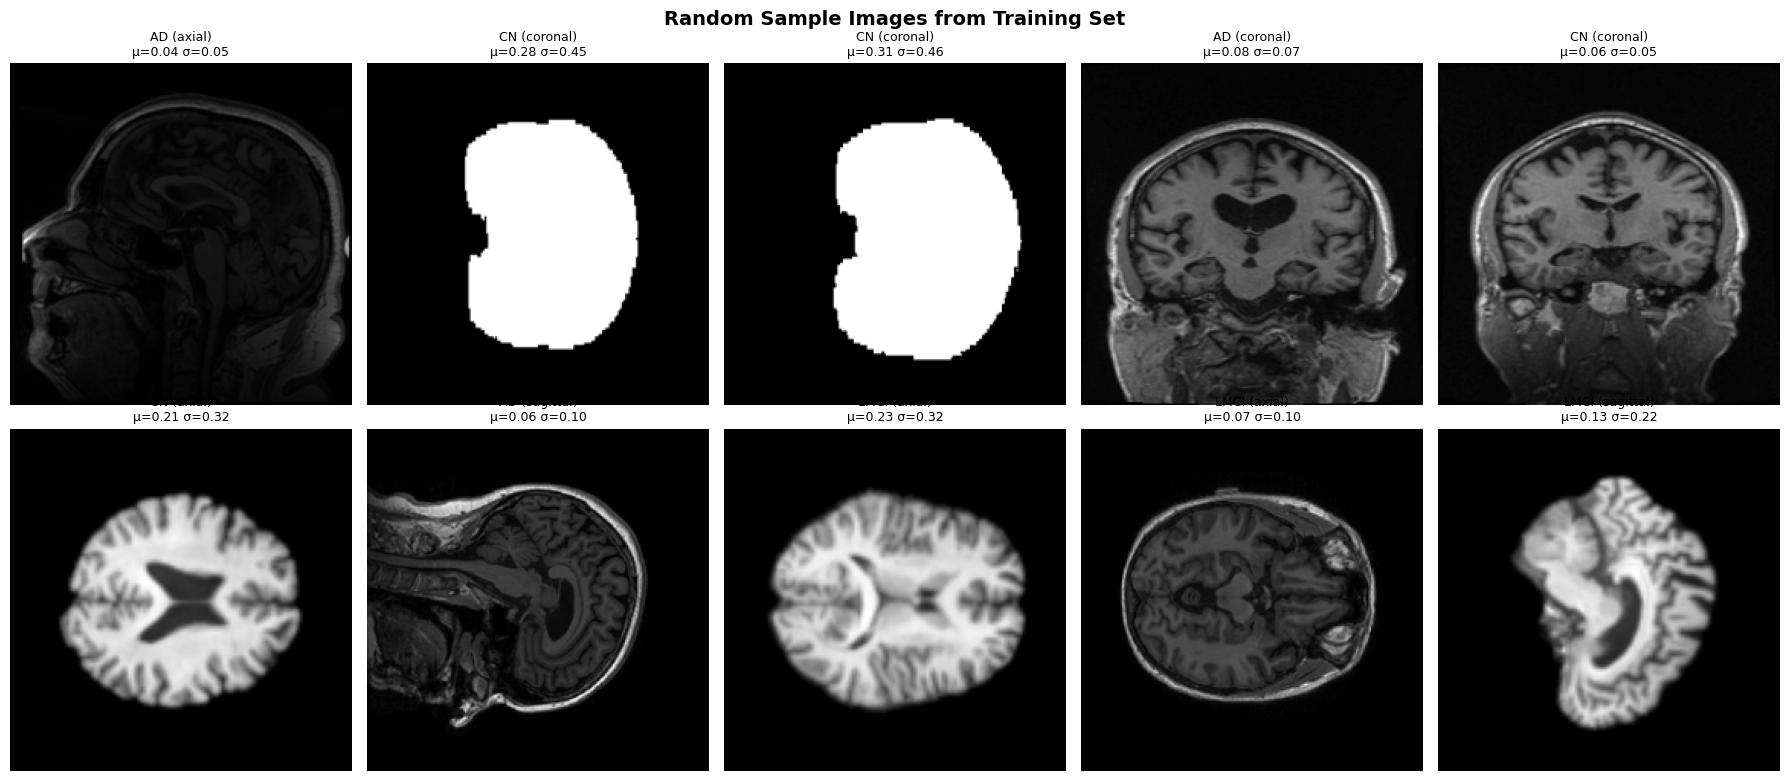


✓ Dataset quality check complete!



In [6]:
# Dataset Quality Check
print('\n' + '='*80)
print('DATASET QUALITY CHECK')
print('='*80)

def check_image_quality(img_path, data_root):
    """Check if image is accessible and get quality metrics."""
    try:
        full_path = os.path.join(data_root, img_path)
        img = Image.open(full_path).convert('RGB')
        arr = np.array(img) / 255.0
        return {
            'status': 'ok',
            'mean': arr.mean(),
            'std': arr.std(),
            'shape': img.size
        }
    except Exception as e:
        return {'status': 'error', 'error': str(e), 'path': full_path}

# Check samples from each split
print('\nChecking image accessibility and quality...')
check_results = {'train': [], 'val': [], 'test': []}

for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    sample_size = min(100, len(df))
    for idx in tqdm(range(sample_size), desc=f'{split_name.capitalize()}'):
        result = check_image_quality(df.iloc[idx]['image_path'], DATA_PATH)
        check_results[split_name].append(result)

# Analyze results
print('\n' + '-'*80)
print('RESULTS:')
for split_name, results in check_results.items():
    ok_count = sum(1 for r in results if r['status'] == 'ok')
    error_count = len(results) - ok_count
    
    # Show first error for debugging
    if error_count > 0:
        first_error = next(r for r in results if r['status'] == 'error')
        print(f'\n{split_name.upper()}: ❌ {error_count} errors')
        print(f'  First error: {first_error["error"]}')
        if 'path' in first_error:
            print(f'  Tried path: {first_error["path"]}')
    
    if ok_count > 0:
        means = [r['mean'] for r in results if r['status'] == 'ok']
        stds = [r['std'] for r in results if r['status'] == 'ok']
        
        print(f'\n{split_name.upper()}:')
        print(f'  Accessible: {ok_count}/{len(results)}')
        print(f'  Errors: {error_count}')
        print(f'  Mean intensity: {np.mean(means):.3f} ± {np.std(means):.3f}')
        print(f'  Std deviation: {np.mean(stds):.3f} ± {np.std(stds):.3f}')
        
        # Check for very dark or white images
        very_dark = sum(1 for m in means if m < 0.1)
        very_bright = sum(1 for m in means if m > 0.9)
        low_contrast = sum(1 for s in stds if s < 0.05)
        
        if very_dark > 0:
            print(f'  ⚠ Very dark images: {very_dark} ({very_dark/len(means)*100:.1f}%)')
        if very_bright > 0:
            print(f'  ⚠ Very bright/white images: {very_bright} ({very_bright/len(means)*100:.1f}%)')
        if low_contrast > 0:
            print(f'  ⚠ Low contrast images: {low_contrast} ({low_contrast/len(stds)*100:.1f}%)')

# Check class balance
print('\n' + '-'*80)
print('CLASS BALANCE CHECK:')
for split_name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'\n{split_name}:')
    counts = df['label'].value_counts()
    max_count = counts.max()
    for cls in CLASSES:
        count = counts.get(cls, 0)
        ratio = max_count / count if count > 0 else float('inf')
        warning = ' ⚠ VERY SMALL' if count < 100 else ''
        print(f'  {cls}: {count:>5} samples (imbalance: {ratio:.1f}:1){warning}')

# Check for image-level leakage (not subject-level)
print('\n' + '-'*80)
print('DATA LEAKAGE CHECK (Image-level):')
train_images = set(train_df['image_path'].unique())
val_images = set(val_df['image_path'].unique())
test_images = set(test_df['image_path'].unique())

train_val_overlap = train_images.intersection(val_images)
train_test_overlap = train_images.intersection(test_images)
val_test_overlap = val_images.intersection(test_images)

if train_val_overlap or train_test_overlap or val_test_overlap:
    print('  ❌ IMAGE LEAKAGE DETECTED!')
    print(f'     Train-Val overlap: {len(train_val_overlap)} images')
    print(f'     Train-Test overlap: {len(train_test_overlap)} images')
    print(f'     Val-Test overlap: {len(val_test_overlap)} images')
else:
    print('  ✅ No image leakage - each image appears in only one split')
    
# Subject overlap is expected and good
train_subjects = set(train_df['subject_id'].unique())
val_subjects = set(val_df['subject_id'].unique())
test_subjects = set(test_df['subject_id'].unique())
print(f'\n  ℹ️  Subject overlap (expected): Train={len(train_subjects)}, '
      f'Val={len(val_subjects)}, Test={len(test_subjects)}')

# Visual sample check
print('\n' + '-'*80)
print('VISUAL SAMPLE CHECK:')
print('Creating visualization of 10 random training samples...\n')

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Random Sample Images from Training Set', fontsize=14, fontweight='bold')

sample_indices = np.random.choice(len(train_df), 10, replace=False)
loaded_count = 0

for idx, ax in enumerate(axes.flat):
    img_path = train_df.iloc[sample_indices[idx]]['image_path']
    label = train_df.iloc[sample_indices[idx]]['label']
    orientation = train_df.iloc[sample_indices[idx]]['orientation']
    
    try:
        img = Image.open(os.path.join(DATA_PATH, img_path))
        arr = np.array(img) / 255.0
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{label} ({orientation})\nμ={arr.mean():.2f} σ={arr.std():.2f}', fontsize=9)
        ax.axis('off')
        loaded_count += 1
    except Exception as e:
        ax.text(0.5, 0.5, f'Error loading\n{str(e)[:30]}', ha='center', va='center', fontsize=8)
        ax.axis('off')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'dataset_samples.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'✅ Successfully loaded {loaded_count}/10 images')
print(f'📁 Saved visualization to: {save_path}')
plt.show()
plt.close()

print('\n✓ Dataset quality check complete!')
print('='*80 + '\n')

In [7]:
# Dataset with strong augmentation
class ADNIDataset(Dataset):
    def __init__(self, df, data_root, orientation='axial', transform=None):
        self.df = df[df['orientation'] == orientation].reset_index(drop=True)
        self.data_root = data_root
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_root, row['image_path'])
        image = Image.open(img_path).convert('RGB')
        label = CLASS_TO_IDX[row['label']]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Strong augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = ADNIDataset(train_df, DATA_PATH, transform=train_transform)
val_dataset = ADNIDataset(val_df, DATA_PATH, transform=val_transform)
test_dataset = ADNIDataset(test_df, DATA_PATH, transform=val_transform)

In [8]:
# Handle class imbalance with WeightedRandomSampler
class_counts = train_dataset.df['label'].value_counts()
class_weights_list = [1.0 / class_counts[cls] for cls in CLASSES]
sample_weights = [class_weights_list[CLASS_TO_IDX[train_dataset.df.iloc[i]['label']]] 
                  for i in range(len(train_dataset))]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, 
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=0, pin_memory=True)

In [9]:
# Model with improved architecture
class ImprovedResNet50(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = models.resnet50(pretrained=True)
        
        # Freeze early layers
        for param in list(self.backbone.parameters())[:-60]:
            param.requires_grad = False
        
        # Replace classifier
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

model = ImprovedResNet50().to(device)

# Calculate boosted class weights
class_weights = torch.tensor(class_weights_list, dtype=torch.float32).to(device)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

# Boost minority classes more
emci_idx = CLASSES.index('EMCI')
lmci_idx = CLASSES.index('LMCI')
class_weights[emci_idx] *= 4.0
class_weights[lmci_idx] *= 5.0
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

print(f'Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 221MB/s]


Model parameters: 19,369,989


In [10]:
# Training with mixed precision
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()
best_val_acc = 0
patience_counter = 0
PATIENCE = 15

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': train_loss/len(pbar), 'acc': 100.*train_correct/train_total})
    
    train_acc = 100. * train_correct / train_total
    train_loss = train_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    val_acc = 100. * val_correct / val_total
    val_loss = val_loss / len(val_loader)
    
    scheduler.step()
    
    # Per-class accuracy
    per_class = {CLASSES[i]: 0 for i in range(NUM_CLASSES)}
    for i in range(NUM_CLASSES):
        mask = np.array(all_labels) == i
        if mask.sum() > 0:
            per_class[CLASSES[i]] = 100. * (np.array(all_preds)[mask] == i).sum() / mask.sum()
    
    print(f'Epoch {epoch+1}: Train Loss={train_loss:.4f}, Acc={train_acc:.2f}% | '
          f'Val Loss={val_loss:.4f}, Acc={val_acc:.2f}%')
    print(f'Per-class: {" | ".join([f"{k}={v:.1f}%" for k,v in per_class.items()])}')
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'best_model.pth'))
        patience_counter = 0
        print(f'✓ Best model saved: {val_acc:.2f}%')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

print(f'\nBest validation accuracy: {best_val_acc:.2f}%')

Epoch 1/30:   0%|          | 0/553 [00:00<?, ?it/s]

Epoch 1: Train Loss=1.1455, Acc=40.65% | Val Loss=1.0705, Acc=43.73%
Per-class: AD=27.5% | CN=0.0% | EMCI=28.1% | LMCI=95.4% | MCI=66.7%
✓ Best model saved: 43.73%


Epoch 2/30:   0%|          | 0/553 [00:00<?, ?it/s]

Epoch 2: Train Loss=1.0361, Acc=47.61% | Val Loss=1.0821, Acc=49.64%
Per-class: AD=1.7% | CN=2.4% | EMCI=60.6% | LMCI=87.1% | MCI=94.8%
✓ Best model saved: 49.64%


Epoch 3/30:   0%|          | 0/553 [00:00<?, ?it/s]

...

Epoch 28: Train Loss=0.4737, Acc=90.11% | Val Loss=0.4223, Acc=92.11%
Per-class: AD=90.8% | CN=87.6% | EMCI=98.3% | LMCI=99.4% | MCI=84.6%


Epoch 29/30:   0%|          | 0/553 [00:00<?, ?it/s]

Epoch 29: Train Loss=0.4720, Acc=89.54% | Val Loss=0.4228, Acc=92.39%
Per-class: AD=90.9% | CN=86.7% | EMCI=97.9% | LMCI=99.6% | MCI=86.8%


Epoch 30/30:   0%|          | 0/553 [00:00<?, ?it/s]

Epoch 30: Train Loss=0.4725, Acc=89.94% | Val Loss=0.4195, Acc=92.62%
Per-class: AD=89.7% | CN=87.6% | EMCI=98.8% | LMCI=99.6% | MCI=87.5%
✓ Best model saved: 92.62%

Best validation accuracy: 92.62%


  0%|          | 0/80 [00:00<?, ?it/s]


Test Accuracy: 92.57%

Classification Report:
              precision    recall  f1-score   support

          AD       0.91      0.88      0.89       504
          CN       0.92      0.90      0.91       498
        EMCI       0.97      0.98      0.97       506
        LMCI       0.96      0.99      0.97       504
         MCI       0.88      0.88      0.88       517

    accuracy                           0.93      2529
   macro avg       0.93      0.93      0.93      2529
weighted avg       0.93      0.93      0.93      2529



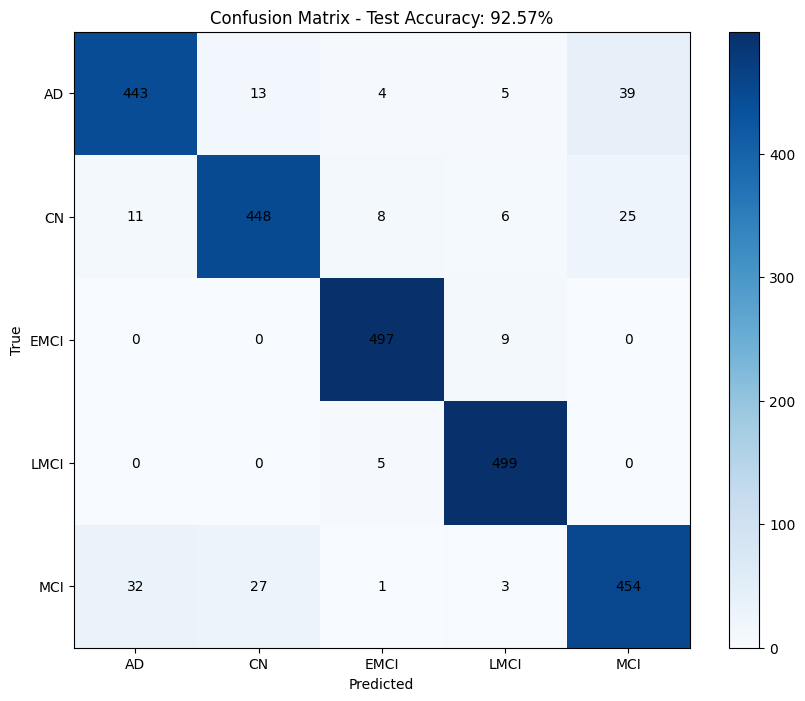

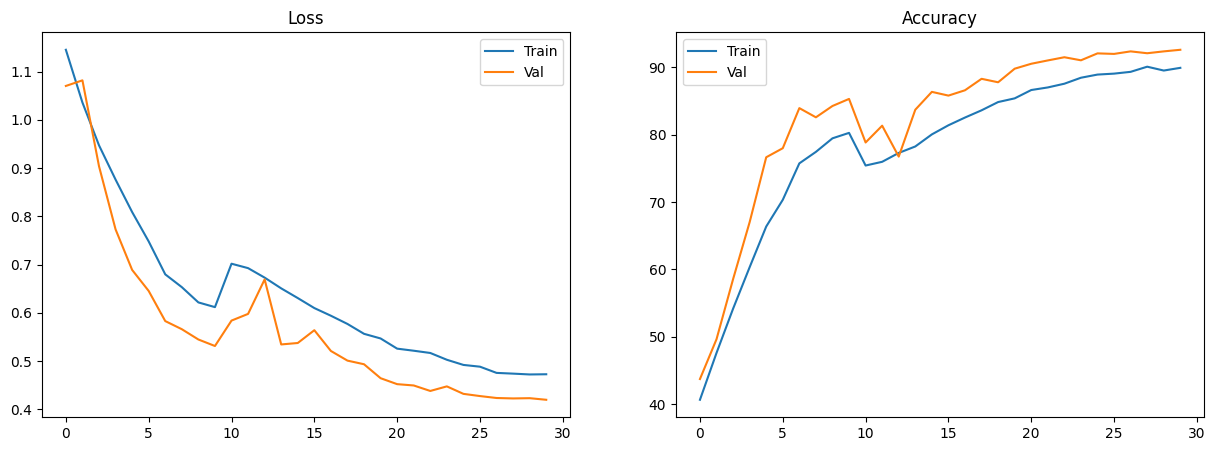

In [11]:
# Test evaluation
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth')))
model.eval()

test_preds, test_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.numpy())

test_acc = accuracy_score(test_labels, test_preds)
print(f'\nTest Accuracy: {test_acc*100:.2f}%')
print(f'\nClassification Report:\n{classification_report(test_labels, test_preds, target_names=CLASSES)}')

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(NUM_CLASSES), CLASSES)
plt.yticks(range(NUM_CLASSES), CLASSES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - Test Accuracy: {test_acc*100:.2f}%')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_title('Loss')
ax1.legend()
ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Val')
ax2.set_title('Accuracy')
ax2.legend()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================================
# SAVE BASELINE OUTPUTS FOR NEXT NOTEBOOKS
# ============================================================================
print('\n' + '='*80)
print('SAVING BASELINE OUTPUTS FOR INTEGRATION')
print('='*80)

# 1. Save trained model with feature extraction capability
baseline_outputs = {
    'model_state_dict': model.state_dict(),
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'history': history,
    'class_to_idx': CLASS_TO_IDX,
    'idx_to_class': IDX_TO_CLASS,
    'classes': CLASSES,
    'image_size': IMAGE_SIZE,
    'num_epochs_trained': len(history['train_loss']),
    'hyperparameters': {
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'dropout': 0.6
    }
}

# Save complete baseline package
baseline_path = os.path.join(OUTPUT_DIR, 'baseline_resnet50.pth')
torch.save(baseline_outputs, baseline_path)
print(f'\n✅ Baseline model saved: {baseline_path}')
print(f'   - Test Accuracy: {test_acc*100:.2f}%')
print(f'   - Val Accuracy: {best_val_acc:.2f}%')

# 2. Extract and save ResNet50 features for ViT integration
print('\n📊 Extracting CNN features for hybrid CNN-ViT model...')

# Modify model to extract features before final classifier
class FeatureExtractor(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        # Get all layers except the custom classifier
        self.features = nn.Sequential(*list(original_model.backbone.children())[:-1])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

feature_extractor = FeatureExtractor(model).to(device)
feature_extractor.eval()

# Extract features from a sample batch for verification
sample_batch, sample_labels = next(iter(test_loader))
sample_batch = sample_batch.to(device)

with torch.no_grad():
    sample_features = feature_extractor(sample_batch)
    
print(f'✅ Feature extraction verified')
print(f'   - Input shape: {sample_batch.shape}')
print(f'   - Feature shape: {sample_features.shape} (2048-dim CNN features)')

# Save feature extractor
feature_extractor_path = os.path.join(OUTPUT_DIR, 'resnet50_feature_extractor.pth')
torch.save({
    'state_dict': feature_extractor.state_dict(),
    'feature_dim': 2048,
    'input_size': IMAGE_SIZE
}, feature_extractor_path)
print(f'✅ Feature extractor saved: {feature_extractor_path}')

# 3. Save data splits for consistency across notebooks
splits_info = {
    'train_csv': os.path.join(OUTPUT_DIR, 'train_balanced.csv'),
    'val_csv': os.path.join(OUTPUT_DIR, 'val_balanced.csv'),
    'test_csv': os.path.join(OUTPUT_DIR, 'test_balanced.csv'),
    'data_path': DATA_PATH,
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'orientations': ORIENTATIONS,
    'current_orientation': 'axial',  # This baseline uses axial only
    'normalization': {
        'mean': IMAGENET_MEAN,
        'std': IMAGENET_STD
    }
}

splits_path = os.path.join(OUTPUT_DIR, 'data_splits_info.json')
with open(splits_path, 'w') as f:
    json.dump(splits_info, f, indent=2)
print(f'✅ Data splits info saved: {splits_path}')

# 4. Save sample images for GradCAM/Attention visualization
print('\n📸 Preparing sample images for visualization notebooks...')

# Select diverse samples from test set (2 per class)
viz_samples = []
for cls in CLASSES:
    cls_samples = test_df[test_df['label'] == cls].sample(min(2, len(test_df[test_df['label'] == cls])), random_state=SEED)
    viz_samples.append(cls_samples)

viz_df = pd.concat(viz_samples, ignore_index=True)
viz_csv_path = os.path.join(OUTPUT_DIR, 'visualization_samples.csv')
viz_df.to_csv(viz_csv_path, index=False)

print(f'✅ Visualization samples saved: {viz_csv_path}')
print(f'   - {len(viz_df)} images ({len(viz_df)//len(CLASSES)} per class)')

# 5. Create integration summary
summary = {
    'baseline_performance': {
        'test_accuracy': float(test_acc),
        'val_accuracy': float(best_val_acc),
        'per_class_results': {}
    },
    'model_architecture': {
        'backbone': 'ResNet50',
        'pretrained': 'ImageNet',
        'trainable_params': sum(p.numel() for p in model.parameters() if p.requires_grad),
        'frozen_layers': 'First 60 layers',
        'classifier': '2048 -> 512 -> 5'
    },
    'for_hybrid_cnn_vit': {
        'cnn_feature_dim': 2048,
        'feature_extractor_path': feature_extractor_path,
        'recommended_vit_config': {
            'patch_size': 16,
            'embed_dim': 768,
            'fusion_strategy': 'concatenate or attention-based',
            'note': 'CNN features can be projected to match ViT dimensions'
        }
    },
    'for_visualization': {
        'model_path': baseline_path,
        'sample_images': viz_csv_path,
        'target_layers': ['backbone.layer4', 'backbone.layer3'],
        'techniques': ['GradCAM', 'GradCAM++', 'Attention Maps']
    },
    'outputs_directory': OUTPUT_DIR
}

summary_path = os.path.join(OUTPUT_DIR, 'integration_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\n✅ Integration summary saved: {summary_path}')

# Print summary
print('\n' + '='*80)
print('BASELINE OUTPUTS READY FOR NEXT STAGES')
print('='*80)
print('\n📦 Files created for CNN-ViT Hybrid:')
print(f'   1. {baseline_path}')
print(f'   2. {feature_extractor_path}')
print(f'   3. {splits_path}')
print(f'   4. CNN feature dim: 2048 → Can fuse with ViT embed_dim (768)')

print('\n📦 Files created for Visualization (GradCAM/Attention):')
print(f'   1. {baseline_path} (model for GradCAM)')
print(f'   2. {viz_csv_path} ({len(viz_df)} samples)')
print(f'   3. Target layers: backbone.layer4, backbone.layer3')

print('\n🎯 Next Steps:')
print('   1. CNN-ViT Hybrid: Load feature_extractor, add ViT, train fusion')
print('   2. Visualization: Load baseline model, apply GradCAM on viz samples')
print('   3. Multi-orientation: Extend to coronal/sagittal, ensemble results')

print('\n' + '='*80)
print(f'📁 All outputs saved to: {OUTPUT_DIR}')
print('='*80)


SAVING BASELINE OUTPUTS FOR INTEGRATION

✅ Baseline model saved: /kaggle/working/phase1_outputs/baseline_resnet50.pth
   - Test Accuracy: 92.57%
   - Val Accuracy: 92.62%

📊 Extracting CNN features for hybrid CNN-ViT model...
✅ Feature extraction verified
   - Input shape: torch.Size([32, 3, 224, 224])
   - Feature shape: torch.Size([32, 2048]) (2048-dim CNN features)
✅ Feature extractor saved: /kaggle/working/phase1_outputs/resnet50_feature_extractor.pth
✅ Data splits info saved: /kaggle/working/phase1_outputs/data_splits_info.json

📸 Preparing sample images for visualization notebooks...
✅ Visualization samples saved: /kaggle/working/phase1_outputs/visualization_samples.csv
   - 10 images (2 per class)

✅ Integration summary saved: /kaggle/working/phase1_outputs/integration_summary.json

BASELINE OUTPUTS READY FOR NEXT STAGES

📦 Files created for CNN-ViT Hybrid:
   1. /kaggle/working/phase1_outputs/baseline_resnet50.pth
   2. /kaggle/working/phase1_outputs/resnet50_feature_extractor

In [13]:
import shutil

# Folder you want to zip
folder_path = "/kaggle/working/phase1_outputs"

# Output zip file location
output_zip = "/kaggle/working/phase1_outputs.zip"

# Create the zip file
shutil.make_archive("/kaggle/working/phase1_outputs", "zip", folder_path)

print("ZIP file created:", output_zip)


ZIP file created: /kaggle/working/phase1_outputs.zip


In [14]:
from IPython.display import FileLink
FileLink("phase1_outputs.zip")


/kaggle/working/phase1_outputs.zip